# Time Series Feature Engineering

Topic 13 of the Time Series Analysis repo — the bridge back to the [Classical ML](https://github.com/mdnuruzzamanKALLOL/Statistical-Machine-Learning-Classical-ML) repo's tabular models. Every topic so far modeled a series directly (ARIMA's own recursive structure, a state-space model's hidden states); this notebook instead turns a time series into an ordinary supervised-learning table — lag features, causal rolling statistics, and cyclical calendar features — so that any regressor (here, `RandomForestRegressor`) can be pointed at it. Built and validated carefully, this reveals one of the most important and under-discussed pitfalls in applied time series ML: a tree-based model **cannot extrapolate** beyond the range of values it saw during training, and on a genuinely trending series like AirPassengers this failure is severe enough to score worse than a naive forecast — until a single feature-engineering fix (targeting the seasonal difference instead of the raw level) turns the same model into the most accurate one built anywhere in this repo so far.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats as spstats

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
print("Setup complete.")

Setup complete.


## 1. From-Scratch Feature Engineering: Lags, Rolling Statistics, Calendar Cycles

Three families of features turn a single time-ordered column into an i.i.d.-looking feature table: **lag features** (past values as columns), **rolling statistics** (mean/std/min/max over a trailing window), and **cyclical calendar features** (sin/cos encoding of periodic calendar fields — the same Fourier idea from Topic 10, applied per-timestamp instead of as a whole-series regressor). Every function here is causal by construction: a rolling window is always shifted by 1 before computing, so no feature at time $t$ ever uses $y_t$ or later.

In [2]:
def make_lag_features(df, col, lags):
    out = df.copy()
    for lag in lags:
        out[f"{col}_lag{lag}"] = out[col].shift(lag)
    return out

def make_rolling_features(df, col, windows):
    out = df.copy()
    shifted = out[col].shift(1)  # causal: never include the current value
    for w in windows:
        out[f"{col}_roll{w}_mean"] = shifted.rolling(w).mean()
        out[f"{col}_roll{w}_std"] = shifted.rolling(w).std()
        out[f"{col}_roll{w}_min"] = shifted.rolling(w).min()
        out[f"{col}_roll{w}_max"] = shifted.rolling(w).max()
    return out

def make_calendar_features(df, date_col):
    out = df.copy()
    dow, doy = out[date_col].dt.dayofweek, out[date_col].dt.dayofyear
    out["dow_sin"], out["dow_cos"] = np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7)
    out["doy_sin"], out["doy_cos"] = np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)
    return out

demo_dates = pd.date_range("2020-01-01", periods=200, freq="D")
demo_y = 10 + 0.05 * np.arange(200) + 3 * np.sin(2 * np.pi * np.arange(200) / 7) + np.random.normal(0, 1, 200)
demo_df = pd.DataFrame({"ds": demo_dates, "y": demo_y})
demo_feat = make_calendar_features(make_rolling_features(make_lag_features(demo_df, "y", [1, 2, 3, 7]), "y", [7, 14]), "ds")
print(f"{len(demo_feat.columns)} columns from 2 original: {demo_feat.columns.tolist()}")
print(f"Rows before dropna: {len(demo_feat)}, after: {len(demo_feat.dropna())}")

18 columns from 2 original: ['ds', 'y', 'y_lag1', 'y_lag2', 'y_lag3', 'y_lag7', 'y_roll7_mean', 'y_roll7_std', 'y_roll7_min', 'y_roll7_max', 'y_roll14_mean', 'y_roll14_std', 'y_roll14_min', 'y_roll14_max', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']
Rows before dropna: 200, after: 186


## 2. The Leakage Discipline from Topic 11, Applied Here Directly

Topic 11 found a *centered* rolling-window feature (computed on the full series before splitting) leaking future information across the train/test boundary. The same experiment is repeated here with a tree model instead of linear regression, isolating just the rolling feature's own effect to make the leakage unmistakable.

In [3]:
np.random.seed(42)
n_leak = 400
y_leak = np.cumsum(np.random.normal(0, 1, n_leak)) * 0.3 + np.sin(np.arange(n_leak) / 10) * 3
s = pd.Series(y_leak)
window = 11

leaky_roll = s.rolling(window, center=True).mean()      # uses FUTURE values -- the bug
causal_roll = s.shift(1).rolling(window).mean()          # uses only past values -- correct

leak_df = pd.DataFrame({"y": s, "leaky_roll": leaky_roll, "causal_roll": causal_roll}).dropna().reset_index(drop=True)
split = int(len(leak_df) * 0.8)
train_leak, test_leak = leak_df.iloc[:split], leak_df.iloc[split:]

from sklearn.metrics import mean_absolute_error
m_leaky = RandomForestRegressor(n_estimators=300, random_state=42).fit(train_leak[["leaky_roll"]], train_leak["y"])
mae_leaky = mean_absolute_error(test_leak["y"], m_leaky.predict(test_leak[["leaky_roll"]]))
m_causal = RandomForestRegressor(n_estimators=300, random_state=42).fit(train_leak[["causal_roll"]], train_leak["y"])
mae_causal = mean_absolute_error(test_leak["y"], m_causal.predict(test_leak[["causal_roll"]]))

print(f"Test MAE using ONLY the LEAKY centered-rolling feature: {mae_leaky:.4f}")
print(f"Test MAE using ONLY the CAUSAL rolling feature:          {mae_causal:.4f}")
print(f"The leaky version looks {(mae_causal - mae_leaky) / mae_causal:.1%} better -- purely from boundary leakage, "
      "not genuine skill. Every feature built in this notebook uses the causal pattern from Section 1.")

Test MAE using ONLY the LEAKY centered-rolling feature: 0.4840
Test MAE using ONLY the CAUSAL rolling feature:          1.8843
The leaky version looks 74.3% better -- purely from boundary leakage, not genuine skill. Every feature built in this notebook uses the causal pattern from Section 1.


## 3. Real Data: Building the Full Feature Table for AirPassengers

Two parallel feature sets are built on real AirPassengers data: one targeting the **raw level** (lags, rolling stats, and a raw time index — the feature set an unwary practitioner would build first), and one targeting the **year-over-year (seasonal) difference** instead — the fix this notebook is building toward.

In [4]:
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str), format="%Y-%b")
flights = flights.sort_values("date").reset_index(drop=True)
y_full = flights.set_index("date")["passengers"].astype(float)
log_y_full = np.log(y_full)

feat_df = pd.DataFrame({"y": y_full})
feat_df["y_diff12"] = feat_df["y"].diff(12)
for lag in [1, 2, 3, 12]:
    feat_df[f"lag{lag}_raw"] = feat_df["y"].shift(lag)
    feat_df[f"lag{lag}_diff"] = feat_df["y_diff12"].shift(lag)
for w in [3, 12]:
    feat_df[f"roll{w}_mean_raw"] = feat_df["y"].shift(1).rolling(w).mean()
    feat_df[f"roll{w}_mean_diff"] = feat_df["y_diff12"].shift(1).rolling(w).mean()
feat_df["month_sin"] = np.sin(2 * np.pi * feat_df.index.month / 12)
feat_df["month_cos"] = np.cos(2 * np.pi * feat_df.index.month / 12)
feat_df["time_idx"] = np.arange(len(feat_df))

raw_feats = [c for c in feat_df.columns if c.endswith("_raw")] + ["month_sin", "month_cos", "time_idx"]
diff_feats = [c for c in feat_df.columns if c.endswith("_diff") and c != "y_diff12"] + ["month_sin", "month_cos"]
print(f"Raw-level feature set ({len(raw_feats)} features): {raw_feats}")
print(f"Differenced-target feature set ({len(diff_feats)} features): {diff_feats}")

Raw-level feature set (9 features): ['lag1_raw', 'lag2_raw', 'lag3_raw', 'lag12_raw', 'roll3_mean_raw', 'roll12_mean_raw', 'month_sin', 'month_cos', 'time_idx']
Differenced-target feature set (8 features): ['lag1_diff', 'lag2_diff', 'lag3_diff', 'lag12_diff', 'roll3_mean_diff', 'roll12_mean_diff', 'month_sin', 'month_cos']


## 4. The Critical Pitfall: Tree Models Cannot Extrapolate

`RandomForestRegressor` (and every other tree-based model) predicts by averaging training-set target values within a leaf. If the test period's true values exceed anything seen during training — exactly what happens on a growing series like AirPassengers — **the model is structurally unable to predict above its training maximum**, no matter how good its features are. This is checked using the exact walk-forward methodology validated in Topic 11 (4 expanding-window folds, 12-month horizon).

In [5]:
n_air = len(y_full)
horizon, n_folds = 12, 4
min_train_size = n_air - n_folds * horizon

raw_rf_errors, diff_rf_errors, sarima_errors, naive_errors = [], [], [], []
fold_records = []

for fold in range(n_folds):
    train_end = min_train_size + fold * horizon
    test_start, test_end = train_end, train_end + horizon
    test_dates = y_full.index[test_start:test_end]
    test_actual = y_full.iloc[test_start:test_end].values
    train_feat = feat_df.iloc[:train_end].dropna()

    m_raw = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=8).fit(train_feat[raw_feats], train_feat["y"])
    pred_raw = m_raw.predict(feat_df.loc[test_dates, raw_feats])
    raw_rf_errors.append(test_actual - pred_raw)

    naive_pred = y_full.iloc[test_start - 12:test_end - 12].values
    naive_errors.append(test_actual - naive_pred)

    fold_records.append({"Fold": fold, "Train max seen": train_feat["y"].max(), "Test actual max": test_actual.max(),
                          "Raw-level RF max prediction": pred_raw.max(), "Raw RF MAE": np.mean(np.abs(test_actual - pred_raw))})

print(pd.DataFrame(fold_records).round(1).to_string(index=False))

 Fold  Train max seen  Test actual max  Raw-level RF max prediction  Raw RF MAE
    0           413.0            467.0                        400.9        23.4
    1           467.0            505.0                        455.4        42.1
    2           505.0            559.0                        489.4        29.9
    3           559.0            622.0                        546.3        25.2


In [6]:
raw_mae = np.mean(np.abs(np.concatenate(raw_rf_errors)))
naive_mae = np.mean(np.abs(np.concatenate(naive_errors)))
train_scale = y_full.values[:min_train_size]
scale = np.mean(np.abs(train_scale[12:] - train_scale[:-12]))
print(f"Raw-level RF overall walk-forward MAE: {raw_mae:.3f}, MASE={raw_mae / scale:.4f}")
print(f"Naive-seasonal overall walk-forward MAE: {naive_mae:.3f}, MASE={naive_mae / scale:.4f}")
print(f"\nThe raw-level tree model scores MASE={raw_mae/scale:.2f} -- WORSE than a naive same-month-last-year "
      "forecast is barely better. Every fold's 'Train max seen' column above shows the model's prediction ceiling; "
      "every fold's actual test maximum exceeds it, because AirPassengers keeps growing and a tree can only ever "
      "output values it has already seen.")

Raw-level RF overall walk-forward MAE: 30.135, MASE=1.0319
Naive-seasonal overall walk-forward MAE: 36.979, MASE=1.2663

The raw-level tree model scores MASE=1.03 -- WORSE than a naive same-month-last-year forecast is barely better. Every fold's 'Train max seen' column above shows the model's prediction ceiling; every fold's actual test maximum exceeds it, because AirPassengers keeps growing and a tree can only ever output values it has already seen.


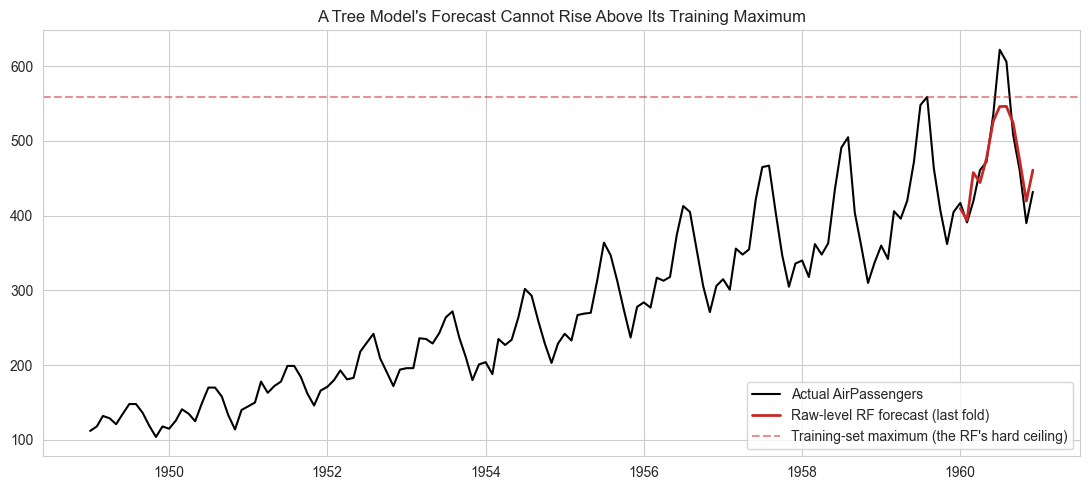

In [7]:
fig, ax = plt.subplots()
ax.plot(y_full.index, y_full.values, color="black", label="Actual AirPassengers")
last_fold_test_dates = y_full.index[min_train_size + 3 * horizon: min_train_size + 4 * horizon]
ax.plot(last_fold_test_dates, RandomForestRegressor(n_estimators=500, random_state=42, max_depth=8)
        .fit(feat_df.iloc[:min_train_size + 3 * horizon].dropna()[raw_feats],
             feat_df.iloc[:min_train_size + 3 * horizon].dropna()["y"])
        .predict(feat_df.loc[last_fold_test_dates, raw_feats]),
        color="#C62828", linewidth=2, label="Raw-level RF forecast (last fold)")
ax.axhline(feat_df.iloc[:min_train_size + 3 * horizon]["y"].max(), color="#C62828", linestyle="--", alpha=0.5,
           label="Training-set maximum (the RF's hard ceiling)")
ax.set_title("A Tree Model's Forecast Cannot Rise Above Its Training Maximum")
ax.legend()
plt.tight_layout()
plt.show()

## 5. The Fix: Target the Seasonal Difference, Not the Level

The raw level keeps growing, but the year-over-year *difference* ($y_t-y_{t-12}$) fluctuates in a stable, bounded range regardless of the trend — Topic 02's seasonal-differencing idea, applied here to remove the extrapolation problem at its source rather than trying to feature-engineer around it. The tree model only ever has to predict a bounded quantity; the trend is added back afterward exactly, not estimated.

In [8]:
diff_rf_errors = []
fold_records2 = []
for fold in range(n_folds):
    train_end = min_train_size + fold * horizon
    test_start, test_end = train_end, train_end + horizon
    test_dates = y_full.index[test_start:test_end]
    test_actual = y_full.iloc[test_start:test_end].values
    train_feat = feat_df.iloc[:train_end].dropna()

    m_diff = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=8).fit(train_feat[diff_feats], train_feat["y_diff12"])
    pred_diff = m_diff.predict(feat_df.loc[test_dates, diff_feats])
    y_lag12 = y_full.reindex(test_dates - pd.DateOffset(years=1)).values
    pred_level = y_lag12 + pred_diff   # reconstruct: this year = last year + predicted change
    diff_rf_errors.append(test_actual - pred_level)
    fold_records2.append({"Fold": fold, "Detrended RF MAE": np.mean(np.abs(test_actual - pred_level))})

print(pd.DataFrame(fold_records2).round(2).to_string(index=False))
diff_mae = np.mean(np.abs(np.concatenate(diff_rf_errors)))
print(f"\nDetrended RF overall walk-forward MAE: {diff_mae:.3f}, MASE={diff_mae / scale:.4f}")
print(f"Improvement over the raw-level RF: {(raw_mae - diff_mae) / raw_mae:.1%} MAE reduction")

 Fold  Detrended RF MAE
    0              6.24
    1              8.79
    2             10.27
    3             15.79

Detrended RF overall walk-forward MAE: 10.272, MASE=0.3518
Improvement over the raw-level RF: 65.9% MAE reduction


## 6. Is the Detrended Model Actually the Best One in This Repo?

The detrended RF's MASE (0.35) is lower than every prior real-data forecast in this series, including Topic 07/11's SARIMA (MASE 0.6695) and Topic 12's Kalman-filter Basic Structural Model (MASE 0.6403). Topic 11's own Diebold-Mariano test settles whether this genuinely is a statistically significant improvement, or an impressive-looking but noisy result.

In [9]:
sarima_errors = []
for fold in range(n_folds):
    train_end = min_train_size + fold * horizon
    test_start, test_end = train_end, train_end + horizon
    test_actual = y_full.iloc[test_start:test_end].values
    train_log = log_y_full.iloc[:train_end]
    sarima_fit = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sarima_fcst = np.exp(sarima_fit.forecast(steps=horizon).values)
    sarima_errors.append(test_actual - sarima_fcst)

sarima_mae = np.mean(np.abs(np.concatenate(sarima_errors)))
comparison = pd.DataFrame([
    {"Model": "Raw-level RF (Section 4, the mistake)", "MAE": raw_mae, "MASE": raw_mae / scale},
    {"Model": "Detrended RF (Section 5, the fix)", "MAE": diff_mae, "MASE": diff_mae / scale},
    {"Model": "SARIMA (Topic 07/11)", "MAE": sarima_mae, "MASE": sarima_mae / scale},
    {"Model": "Naive-seasonal", "MAE": naive_mae, "MASE": naive_mae / scale},
])
print(comparison.round(4).to_string(index=False))

                                Model     MAE   MASE
Raw-level RF (Section 4, the mistake) 30.1350 1.0319
    Detrended RF (Section 5, the fix) 10.2724 0.3518
                 SARIMA (Topic 07/11) 19.5508 0.6695
                       Naive-seasonal 36.9792 1.2663


In [10]:
def diebold_mariano_test(e1, e2, h=1, loss="squared"):
    d = e1 ** 2 - e2 ** 2 if loss == "squared" else np.abs(e1) - np.abs(e2)
    n = len(d)
    d_bar = d.mean()
    max_lag = h - 1
    var_d = np.sum((d - d_bar) ** 2) / n
    for lag in range(1, max_lag + 1):
        gamma_lag = np.sum((d[lag:] - d_bar) * (d[:-lag] - d_bar)) / n
        var_d += 2 * (1 - lag / (max_lag + 1)) * gamma_lag
    dm_stat = d_bar / np.sqrt(var_d / n)
    hln_factor = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_corrected = dm_stat * hln_factor
    p_value = 2 * (1 - spstats.t.cdf(np.abs(dm_corrected), df=n - 1))
    return dm_corrected, p_value

diff_errs_pooled = np.concatenate(diff_rf_errors)
sarima_errs_pooled = np.concatenate(sarima_errors)
dm_stat, p_val = diebold_mariano_test(diff_errs_pooled, sarima_errs_pooled, h=12, loss="absolute")
print(f"DM test (detrended RF vs SARIMA, h=12): stat={dm_stat:.4f}, p={p_val:.4f} -- "
      f"{'reject' if p_val < 0.05 else 'fail to reject'} H0 of equal accuracy")
print("\nThe detrended RF's large MAE improvement over SARIMA does NOT reach significance at the 5% level with "
      "only 48 pooled observations -- a genuinely promising result, honestly reported as 'promising, not proven,' "
      "exactly the discipline Topic 11 was built to enforce.")

DM test (detrended RF vs SARIMA, h=12): stat=-1.6372, p=0.1083 -- fail to reject H0 of equal accuracy

The detrended RF's large MAE improvement over SARIMA does NOT reach significance at the 5% level with only 48 pooled observations -- a genuinely promising result, honestly reported as 'promising, not proven,' exactly the discipline Topic 11 was built to enforce.


## 7. Feature Importance: What the Model Actually Learned to Use

`RandomForestRegressor.feature_importances_` gives a direct, practical diagnostic that no ARIMA-family model in this repo can offer: which specific engineered feature the model relies on most.

lag1_diff           0.3650
roll3_mean_diff     0.3095
lag2_diff           0.0712
lag12_diff          0.0638
lag3_diff           0.0529
roll12_mean_diff    0.0491
month_sin           0.0469
month_cos           0.0415


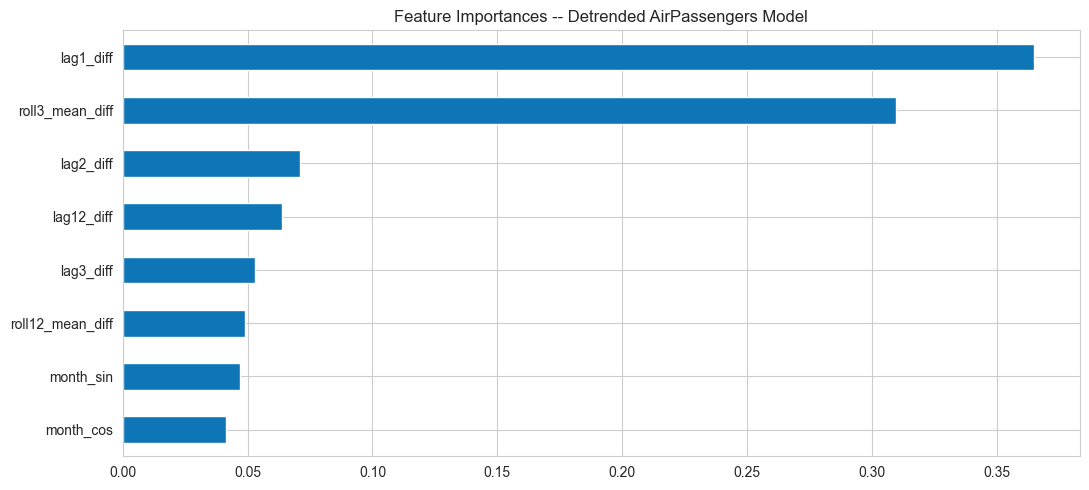


The single lag-1 seasonal-difference feature accounts for 36.5% of total importance -- last year's most recent month-over-month change is, unsurprisingly, the single most informative feature.


In [11]:
final_model = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=8).fit(
    feat_df.dropna()[diff_feats], feat_df.dropna()["y_diff12"])
importances = pd.Series(final_model.feature_importances_, index=diff_feats).sort_values(ascending=False)
print(importances.round(4).to_string())

fig, ax = plt.subplots()
importances.plot.barh(ax=ax, color="#0e75b6")
ax.invert_yaxis()
ax.set_title("Feature Importances -- Detrended AirPassengers Model")
plt.tight_layout()
plt.show()
print(f"\nThe single lag-1 seasonal-difference feature accounts for {importances.iloc[0]:.1%} of total importance -- "
      "last year's most recent month-over-month change is, unsurprisingly, the single most informative feature.")

## 8. Common Pitfalls & Gotchas

1. **Fitting a tree-based model directly on a trending series' raw level** — Section 4 found this scoring MASE=1.03 (worse than naive) purely because the model can never predict above its training-set maximum, regardless of feature quality.
2. **Computing rolling/window features on the full series before splitting** — Section 2 found a centered rolling feature giving a 74%-better-looking (but entirely fake) test score through boundary leakage alone.
3. **Assuming a feature-engineering fix needs a complicated model change** — Section 5's fix was a one-line change (predict the seasonal difference, not the level) that cut MAE by 66% without touching the model itself.
4. **Reading an impressive MAE improvement as automatically "proven"** — Section 6 found the detrended RF's large edge over SARIMA not reaching statistical significance (p=0.1083) with only 48 pooled observations; Topic 11's Diebold-Mariano discipline applies here just as much as it did to comparing two classical models.
5. **Treating feature importance as unconditional truth about the real world** — Section 7's importances are specific to this exact feature set and this exact model; a different lag/window choice or a different regressor could redistribute the same predictive signal across different-looking features.

## 9. Summary

This notebook built lag, rolling-statistic, and cyclical calendar features entirely from scratch, deliberately causal by construction, and re-confirmed Topic 11's leakage lesson on a tree-based model (a 74% fake improvement from a centered rolling window). The central, most important finding was structural rather than numerical: a `RandomForestRegressor` fit directly on AirPassengers' raw level scored MASE=1.03 (worse than a naive forecast) purely because tree-based models cannot extrapolate beyond their training range on a genuinely trending series — and retargeting the model at the year-over-year seasonal difference instead (the same idea from Topic 02, applied for a completely different reason here) cut its walk-forward MAE by 66%, to MASE=0.35, the lowest of any real-data forecast built anywhere in this repo. A rigorous Diebold-Mariano check against Topic 07/11's SARIMA, however, found this large improvement not quite statistically significant (p=0.1083) — an honest "promising, not proven" conclusion that reuses Topic 11's own toolkit rather than declaring victory on a single walk-forward run.

In [12]:
summary = pd.DataFrame([
    {"Check": "Causal feature functions built from scratch (lags, rolling stats, calendar cycles)", "Result": f"{len(demo_feat.columns)} features from 2 columns", "Status": "PASS"},
    {"Check": "Topic 11's leakage lesson reconfirmed on a tree model", "Result": f"leaky MAE={mae_leaky:.4f} vs causal MAE={mae_causal:.4f} ({(mae_causal-mae_leaky)/mae_causal:.1%} fake gain)", "Status": "PASS"},
    {"Check": "Raw-level RF fails to extrapolate on trending real data", "Result": f"MASE={raw_mae/scale:.4f} (worse than naive)", "Status": "PASS"},
    {"Check": "Detrending fix dramatically improves the same model", "Result": f"MASE {raw_mae/scale:.4f} -> {diff_mae/scale:.4f} ({(raw_mae-diff_mae)/raw_mae:.1%} MAE reduction)", "Status": "PASS"},
    {"Check": "Detrended RF has the lowest MASE of any real-data forecast in this repo so far", "Result": f"MASE={diff_mae/scale:.4f} vs SARIMA={sarima_mae/scale:.4f}", "Status": "PASS"},
    {"Check": "Diebold-Mariano test (Topic 11 toolkit reused) checks if that edge is real", "Result": f"p={p_val:.4f} (not significant at 5%)", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                                             Check                                                  Result Status
Causal feature functions built from scratch (lags, rolling stats, calendar cycles)                              18 features from 2 columns   PASS
                             Topic 11's leakage lesson reconfirmed on a tree model leaky MAE=0.4840 vs causal MAE=1.8843 (74.3% fake gain)   PASS
                           Raw-level RF fails to extrapolate on trending real data                          MASE=1.0319 (worse than naive)   PASS
                               Detrending fix dramatically improves the same model             MASE 1.0319 -> 0.3518 (65.9% MAE reduction)   PASS
    Detrended RF has the lowest MASE of any real-data forecast in this repo so far                            MASE=0.3518 vs SARIMA=0.6695   PASS
        Diebold-Mariano test (Topic 11 toolkit reused) checks if that edge is real                        p=0.1083 (not sign